In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carica la falda acquifera
grondwater = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Hoog grondwater_geojson_lnglat.json")
print(f"Elementi caricati: {len(grondwater)}")
print(grondwater.columns.tolist())
grondwater.head()

Elementi caricati: 192
['Locatie', 'Drainage', 'geometry']


,Locatie,Drainage,geometry
0,Driemond,Mogelijk,"POLYGON ((5.01512 52.30366, 5.01556 52.30407, ..."
1,Driemond,Mogelijk,"POLYGON ((5.01626 52.30609, 5.0166 52.30715, 5..."
2,Oostelijk Havengebied,Mogelijk,"POLYGON ((4.93418 52.37039, 4.93413 52.37127, ..."
3,Oostelijk Havengebied,Mogelijk,"POLYGON ((4.93906 52.3734, 4.94746 52.37429, 4..."
4,Oostelijk Havengebied,Mogelijk,"POLYGON ((4.94653 52.37686, 4.94099 52.37666, ..."


In [2]:
print(grondwater['Drainage'].value_counts())

Drainage
Mogelijk         105
Niet mogelijk     87
Name: count, dtype: int64


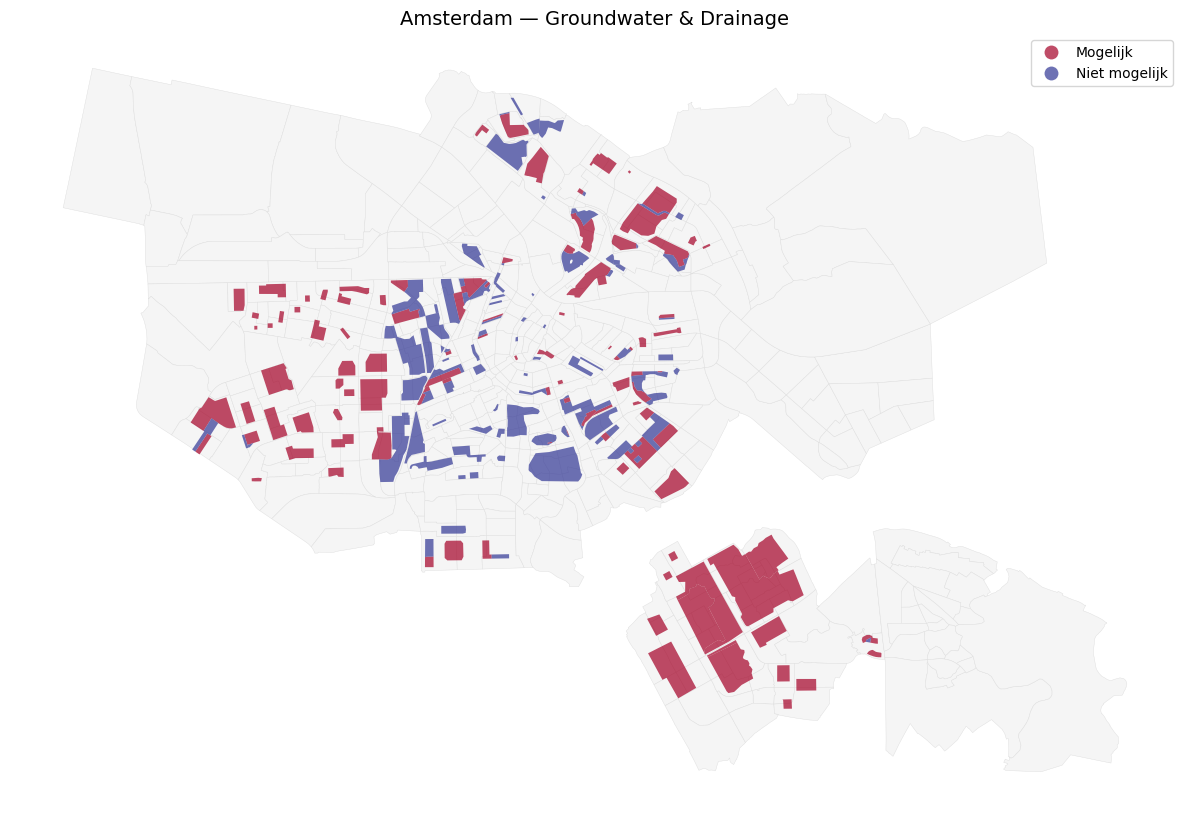

In [3]:
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
grondwater_proj = grondwater.to_crs(buurten.crs)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Sfondo quartieri
buurten.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

# Falda acquifera colorata
grondwater_proj.plot(
    column='Drainage',
    cmap='RdYlBu',
    ax=ax,
    legend=True,
    alpha=0.7
)

ax.set_title('Amsterdam — Groundwater & Drainage', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_groundwater.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
hydro = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Hydro-eenheden_geojson_lnglat.json")
print(f"Elementi caricati: {len(hydro)}")
print(hydro.columns.tolist())
hydro.head()

GEOSException: IllegalArgumentException: Points of LinearRing do not form a closed linestring

In [5]:
hydro = gpd.read_file(
    r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\Hydro-eenheden_geojson_lnglat.json",
    on_invalid="ignore"
)
print(f"Elementi caricati: {len(hydro)}")
print(hydro.columns.tolist())
hydro.head()

Elementi caricati: 67
['HYDRO_ID', 'Afbeelding', 'Toelichting', 'Link_URL', 'PDF', 'PDF2', 'geometry']


,HYDRO_ID,Afbeelding,Toelichting,Link_URL,PDF,PDF2,geometry
0,66,,Oplossingenkaart nog niet beschikbaar.,,,,"POLYGON ((4.82795 52.34675, 4.82789 52.35138, ..."
1,15,,Oplossingenkaart nog niet beschikbaar.,,,,"POLYGON ((4.83392 52.37004, 4.8334 52.36569, 4..."
2,12,,Oplossingenkaart nog niet beschikbaar.,,,,"POLYGON ((4.83073 52.36991, 4.83056 52.37013, ..."
3,67,,Oplossingenkaart nog niet beschikbaar.,,,,"POLYGON ((4.8355 52.37629, 4.83613 52.37621, 4..."
4,17,,Oplossingenkaart nog niet beschikbaar.,,,,"POLYGON ((4.83996 52.38478, 4.84392 52.38489, ..."


In [6]:
# Convertiamo Drainage in numerico
grondwater_proj['falda'] = grondwater_proj['Drainage'].map({
    'Mogelijk': 1,
    'Niet mogelijk': 2
})

# Uniamo ai buurten per posizione
joined_gw = gpd.sjoin(buurten, grondwater_proj[['falda', 'geometry']], 
                       how='left', predicate='intersects')

falda_stadsdeel = joined_gw.groupby('Stadsdeel')['falda'].mean().reset_index()
falda_stadsdeel.columns = ['Stadsdeel', 'Falda_media']

print(falda_stadsdeel.sort_values('Falda_media', ascending=False))

    Stadsdeel  Falda_media
7        Zuid     1.850746
5        West     1.702970
0     Centrum     1.687500
3        Oost     1.551282
2       Noord     1.536232
4       Weesp     1.250000
1  Nieuw-West     1.090909
8    Zuidoost     1.000000
6   Westpoort          NaN


In [7]:
import pandas as pd
from scipy import stats

# Carichiamo le variabili che avevamo già
verde_stadsdeel = gpd.read_file(
    r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\park_geojson_lnglat.json",
    on_invalid="ignore"
).groupby('Stadsdeel')['Oppervlakte_m2'].sum().reset_index()
verde_stadsdeel.columns = ['Stadsdeel', 'Verde_km2']
verde_stadsdeel['Verde_km2'] = verde_stadsdeel['Verde_km2'] / 1_000_000

flood = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\overstroming_geojson_lnglat.json")
flood['rischio'] = flood['Kans'].map({
    'Geen significante overstromingskans': 0,
    'Extreem kleine kans: <1/30.000 per jaar': 1,
    'Zeer kleine kans: 1/3.000 tot 1/30.000 per jaar': 2,
    'Kleine kans: 1/300 tot 1/3.000 per jaar': 3
})
flood_proj = flood.to_crs(buurten.crs)
joined_flood = gpd.sjoin(buurten, flood_proj[['rischio', 'geometry']], 
                          how='left', predicate='intersects')
rischio_stadsdeel = joined_flood.groupby('Stadsdeel')['rischio'].mean().reset_index()
rischio_stadsdeel.columns = ['Stadsdeel', 'Rischio_medio']

# Uniamo tutto
analisi = verde_stadsdeel\
    .merge(rischio_stadsdeel, on='Stadsdeel', how='inner')\
    .merge(falda_stadsdeel, on='Stadsdeel', how='inner')\
    .dropna()

print(analisi)

    Stadsdeel  Verde_km2  Rischio_medio  Falda_media
0     Centrum   0.082263       0.589552     1.687500
1  Nieuw-West   5.862203       1.456349     1.090909
2       Noord   2.726583       1.697479     1.536232
3        Oost   1.849505       0.859848     1.551282
4        West   0.557488       0.970501     1.702970
5        Zuid   1.819623       0.665653     1.850746
6    Zuidoost   5.251325       1.607477     1.000000


In [8]:
# Correlazioni tra tutte le variabili
print("=== CORRELAZIONI ===\n")

# Verde vs Rischio (quella che avevamo già)
r1, p1 = stats.pearsonr(analisi['Verde_km2'], analisi['Rischio_medio'])
print(f"Verde vs Rischio:  r={r1:.3f}, p={p1:.3f}")

# Falda vs Rischio
r2, p2 = stats.pearsonr(analisi['Falda_media'], analisi['Rischio_medio'])
print(f"Falda vs Rischio:  r={r2:.3f}, p={p2:.3f}")

# Verde vs Falda
r3, p3 = stats.pearsonr(analisi['Verde_km2'], analisi['Falda_media'])
print(f"Verde vs Falda:    r={r3:.3f}, p={p3:.3f}")

=== CORRELAZIONI ===

Verde vs Rischio:  r=0.764, p=0.045
Falda vs Rischio:  r=-0.749, p=0.052
Verde vs Falda:    r=-0.904, p=0.005


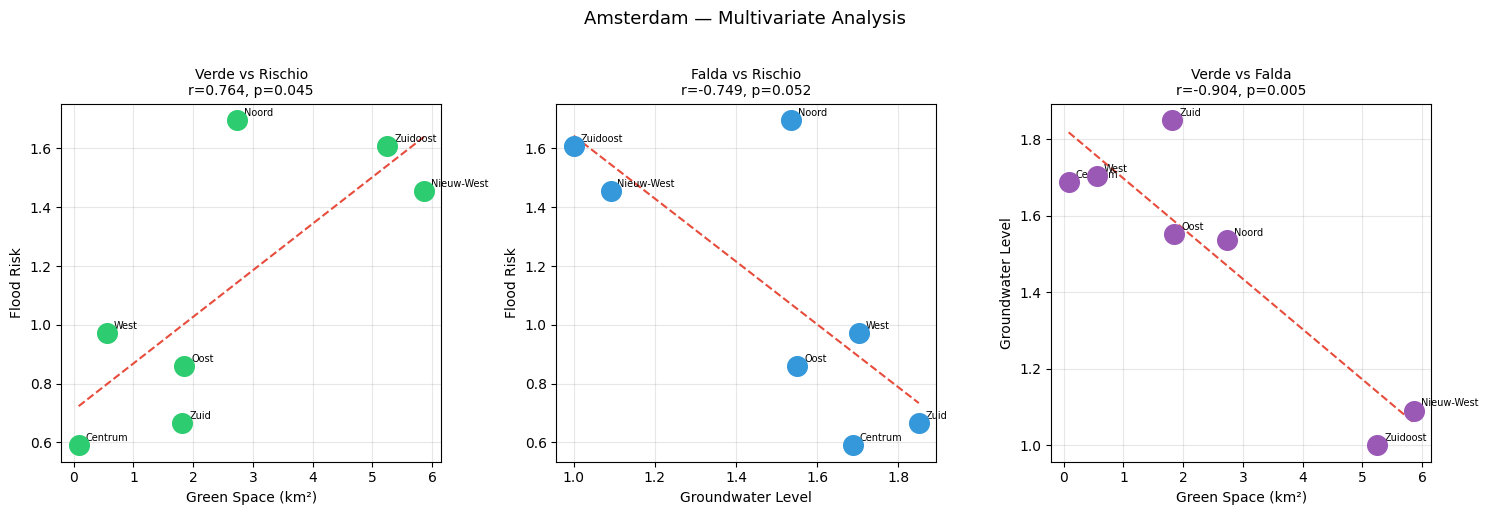

In [11]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Grafico 1 — Verde vs Rischio
axes[0].scatter(analisi['Verde_km2'], analisi['Rischio_medio'], 
                s=200, color='#2ecc71', zorder=5)
for _, row in analisi.iterrows():
    axes[0].annotate(row['Stadsdeel'], 
                     xy=(row['Verde_km2'], row['Rischio_medio']),
                     xytext=(5, 3), textcoords='offset points', fontsize=7)
z = np.polyfit(analisi['Verde_km2'], analisi['Rischio_medio'], 1)
x_line = np.linspace(analisi['Verde_km2'].min(), analisi['Verde_km2'].max(), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), '--', color='#e74c3c', linewidth=1.5)
axes[0].set_title(f'Verde vs Rischio\nr={r1:.3f}, p={p1:.3f}', fontsize=10)
axes[0].set_xlabel('Green Space (km²)')
axes[0].set_ylabel('Flood Risk')
axes[0].grid(True, alpha=0.3)

# Grafico 2 — Falda vs Rischio
axes[1].scatter(analisi['Falda_media'], analisi['Rischio_medio'], 
                s=200, color='#3498db', zorder=5)
for _, row in analisi.iterrows():
    axes[1].annotate(row['Stadsdeel'], 
                     xy=(row['Falda_media'], row['Rischio_medio']),
                     xytext=(5, 3), textcoords='offset points', fontsize=7)
z = np.polyfit(analisi['Falda_media'], analisi['Rischio_medio'], 1)
x_line = np.linspace(analisi['Falda_media'].min(), analisi['Falda_media'].max(), 100)
axes[1].plot(x_line, np.poly1d(z)(x_line), '--', color='#e74c3c', linewidth=1.5)
axes[1].set_title(f'Falda vs Rischio\nr={r2:.3f}, p={p2:.3f}', fontsize=10)
axes[1].set_xlabel('Groundwater Level')
axes[1].set_ylabel('Flood Risk')
axes[1].grid(True, alpha=0.3)

# Grafico 3 — Verde vs Falda
axes[2].scatter(analisi['Verde_km2'], analisi['Falda_media'], 
                s=200, color='#9b59b6', zorder=5)
for _, row in analisi.iterrows():
    axes[2].annotate(row['Stadsdeel'], 
                     xy=(row['Verde_km2'], row['Falda_media']),
                     xytext=(5, 3), textcoords='offset points', fontsize=7)
z = np.polyfit(analisi['Verde_km2'], analisi['Falda_media'], 1)
x_line = np.linspace(analisi['Verde_km2'].min(), analisi['Verde_km2'].max(), 100)
axes[2].plot(x_line, np.poly1d(z)(x_line), '--', color='#e74c3c', linewidth=1.5)
axes[2].set_title(f'Verde vs Falda\nr={r3:.3f}, p={p3:.3f}', fontsize=10)
axes[2].set_xlabel('Green Space (km²)')
axes[2].set_ylabel('Groundwater Level')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Amsterdam — Multivariate Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('amsterdam_multivariate.png', dpi=150, bbox_inches='tight')
plt.show()